# Sidequest: Board & Workforce Racial/Gender Diversity vs. Firm Risk in Brazil

Exploratory side-project, kept deliberately separate from the main thesis (debt-note textual change and market reaction). See `README.md`, `novelty_verification.md`, `extension_plan.md`, and `results_v2.md` in this folder for the full narrative — this notebook is the visual walkthrough of the same results.

**Question**: does board/executive/workforce-leadership racial and gender diversity relate to firm risk (cost of debt, stock return volatility) in Brazilian listed companies, using CVM's actual mandatory disclosure data (Resolução CVM 59/2021, in force since FRE filings made in 2023)?

**Why this question**: a literature scan (first pass + an adversarial second pass specifically trying to disprove it) found this is a genuine, undone gap for Brazil — board *gender* diversity and performance/cost-of-equity is already published (2025-2026), but *racial* diversity tested against any firm outcome using the real regulatory data has not been done. The only prior Brazilian race-and-governance work is a 2022 survey with a 16% response rate.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10
pd.set_option('display.width', 140)

df = pd.read_csv('diversity_analysis_dataset_v2.csv')
results = pd.read_csv('diversity_test_results_v2.csv')
print(f"{len(df)} company-years, {df['CD_CVM'].nunique()} companies, {df['year'].nunique()} fiscal years ({df['year'].min()}-{df['year'].max()})")
df.head()


399 company-years, 104 companies, 4 fiscal years (2023-2026)


,CD_CVM,board_size,pct_female_board,pct_black_brown_board,exec_size,pct_female_exec,pct_black_brown_exec,year,has_black_brown_board,has_black_brown_exec,leadership_n,pct_female_leadership,pct_black_brown_leadership,cost_of_debt_proxy,return_volatility,ln_total_assets,leverage,roa
0,2437,9,0.111111,0.000000,11,0.181818,0.0,2023,0,0,907.0,0.240353,0.237045,0.105501,0.313995,19.402975,0.578875,0.016457
1,2453,11,0.000000,0.090909,7,0.142857,0.0,2023,1,0,199.0,0.185930,0.170854,0.054409,0.268800,17.822845,0.551724,0.104851
2,2577,3,0.000000,0.000000,4,0.500000,0.0,2023,0,0,NaN,NaN,NaN,0.125011,NaN,16.423238,0.413246,-0.033119
3,3980,7,0.142857,0.000000,8,0.000000,0.0,2023,0,0,4610.0,0.243818,0.142733,0.088205,0.291715,18.131466,0.342475,0.100647
4,4030,5,0.000000,0.200000,6,0.000000,0.0,2023,1,0,1269.0,0.133176,0.324665,0.080829,0.405745,18.332174,0.784935,0.004399


## 1. The data: board, executive, and workforce-leadership diversity, 2023-2026

CVM only made this disclosure mandatory in 2021 (Resolução 59, codified as Resolução 80/2022) -- confirmed directly that `fre_cia_aberta_2022.zip` has no gender/race declaration file at all, while 2023 onward does. So the whole usable panel is these 4 fiscal years, not the main thesis's 10.

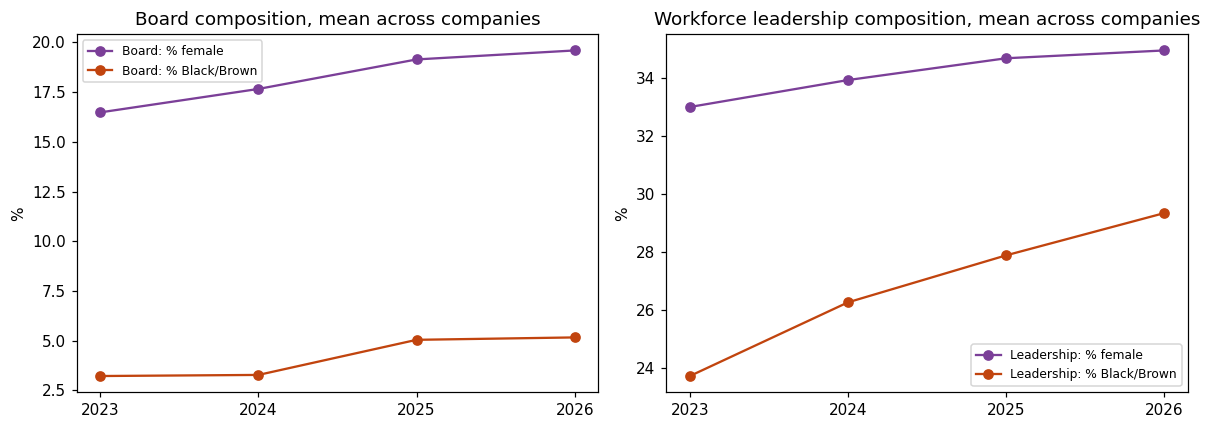

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

trend = df.groupby('year')[['pct_female_board', 'pct_black_brown_board', 'pct_female_leadership', 'pct_black_brown_leadership']].mean()

axes[0].plot(trend.index, trend['pct_female_board']*100, marker='o', label='Board: % female', color='#7B3F98')
axes[0].plot(trend.index, trend['pct_black_brown_board']*100, marker='o', label='Board: % Black/Brown', color='#C1440E')
axes[0].set_title('Board composition, mean across companies')
axes[0].set_ylabel('%')
axes[0].legend(fontsize=8)
axes[0].set_xticks(trend.index)

axes[1].plot(trend.index, trend['pct_female_leadership']*100, marker='o', label='Leadership: % female', color='#7B3F98')
axes[1].plot(trend.index, trend['pct_black_brown_leadership']*100, marker='o', label='Leadership: % Black/Brown', color='#C1440E')
axes[1].set_title('Workforce leadership composition, mean across companies')
axes[1].set_ylabel('%')
axes[1].legend(fontsize=8)
axes[1].set_xticks(trend.index)

plt.tight_layout()
plt.savefig('figures/diversity_trends.png', bbox_inches='tight')
plt.show()


**Board gender representation rose steadily**: 16.5% (2023) to 19.6% (2026). Racial diversity did not show a comparably clean trend at the board level. Workforce leadership (hundreds of employees per company, not ~7 board members) shows a very different, much less noisy picture -- exactly why it was added in the extension.

## 2. The striking baseline fact: board racial diversity is zero for most companies

This is true before any hypothesis test runs.

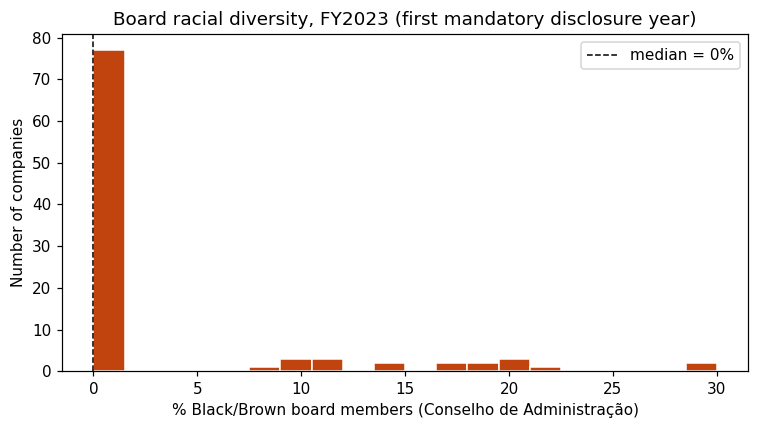

Median board racial diversity, 2023: 0.0%
Share of companies with ZERO Black/Brown board members: 80.2%
For comparison: Black + Brown Brazilians are ~56% of the population (IBGE)


In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
board_2023 = df[df['year']==2023]['pct_black_brown_board'].dropna()
ax.hist(board_2023*100, bins=20, color='#C1440E', edgecolor='white')
ax.axvline(board_2023.median()*100, color='black', linestyle='--', linewidth=1, label=f'median = {board_2023.median()*100:.0f}%')
ax.set_xlabel('% Black/Brown board members (Conselho de Administração)')
ax.set_ylabel('Number of companies')
ax.set_title('Board racial diversity, FY2023 (first mandatory disclosure year)')
ax.legend()
plt.tight_layout()
plt.savefig('figures/board_race_histogram.png', bbox_inches='tight')
plt.show()

print(f"Median board racial diversity, 2023: {board_2023.median()*100:.1f}%")
print(f"Share of companies with ZERO Black/Brown board members: {(board_2023==0).mean()*100:.1f}%")
print(f"For comparison: Black + Brown Brazilians are ~56% of the population (IBGE)")


This matches Gouvêa (2022)'s earlier survey finding (zero Black board members, ~1% Brown, out of a 16%-response-rate sample) -- now confirmed at 101-104/111 company coverage instead of 69/442.

## 3. Outcome variables: cost of debt proxy and return volatility

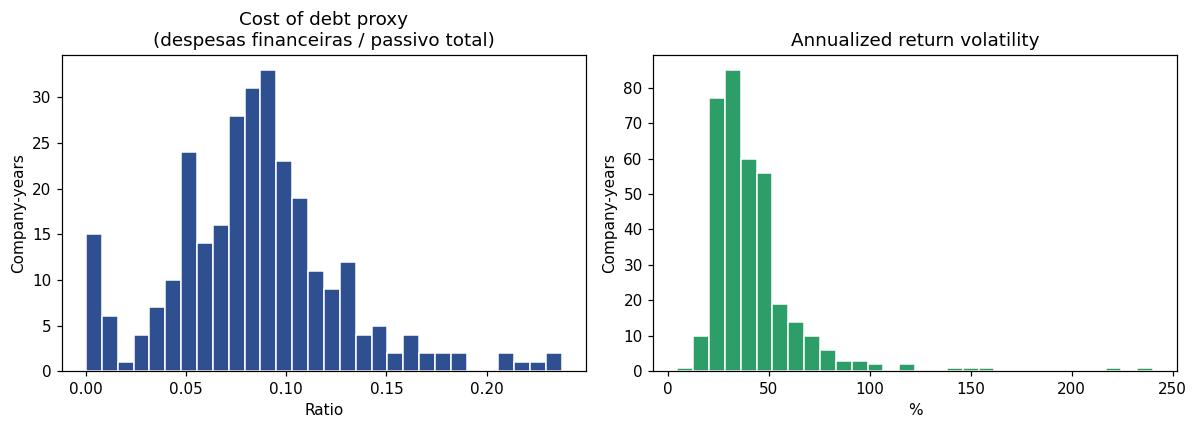

count    296.000000
mean       0.089083
std        0.050765
min        0.000000
25%        0.060564
50%        0.084420
75%        0.107803
max        0.350380
Name: cost_of_debt_proxy, dtype: float64

count    353.000000
mean       0.421068
std        0.244363
min        0.046966
25%        0.282667
50%        0.365873
75%        0.478922
max        2.402583
Name: return_volatility, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

cod = df['cost_of_debt_proxy'].dropna()
axes[0].hist(cod, bins=30, color='#2E5090', edgecolor='white', range=(0, cod.quantile(0.98)))
axes[0].set_title('Cost of debt proxy\n(despesas financeiras / passivo total)')
axes[0].set_xlabel('Ratio')
axes[0].set_ylabel('Company-years')

vol = df['return_volatility'].dropna()
axes[1].hist(vol*100, bins=30, color='#2E9E68', edgecolor='white')
axes[1].set_title('Annualized return volatility')
axes[1].set_xlabel('%')
axes[1].set_ylabel('Company-years')

plt.tight_layout()
plt.savefig('figures/outcome_distributions.png', bbox_inches='tight')
plt.show()

print(cod.describe())
print()
print(vol.describe())


## 4. The test battery: signed correlation → clustered regression → controls → fixed effects

Same rigor progression the main thesis uses throughout. Two results looked real through three stages and were caught by the fourth.

In [5]:
pivot = results.pivot_table(
    index=['outcome', 'predictor'],
    values=['simple_p', 'clustered_no_controls_p', 'clustered_with_controls_p', 'fe_p'],
)[['simple_p', 'clustered_no_controls_p', 'clustered_with_controls_p', 'fe_p']]
pivot.columns = ['Simple corr.', 'Clustered', '+ Controls', 'Fixed effects']
pivot.round(3)


Simple corr.  Clustered  + Controls  Fixed effects
outcome            predictor                                                                     
cost_of_debt_proxy has_black_brown_board              0.445      0.512       0.373          0.122
                   pct_black_brown_board              0.904      0.877       0.827          0.204
                   pct_black_brown_exec               0.153      0.381       0.397          0.903
                   pct_black_brown_leadership         0.392      0.530       0.547          0.707
                   pct_female_board                   0.609      0.648       0.714          0.744
                   pct_female_exec                    0.315      0.418       0.350          0.407
                   pct_female_leadership              0.142      0.294       0.262          0.840
return_volatility  has_black_brown_board              0.030      0.078       0.406          0.963
                   pct_black_brown_board              0.419      0.451       0.952          0.988
                   pct_black_brown_exec               0.112      0.116       0.001          0.580
                   pct_black_brown_leadership         0.001      0.096       0.172          0.636
                   pct_female_board                   0.103      0.375       0.725          0.529
                   pct_female_exec                    0.296      0.594       0.495          0.381
                   pct_female_leadership              0.000      0.002       0.004          0.394

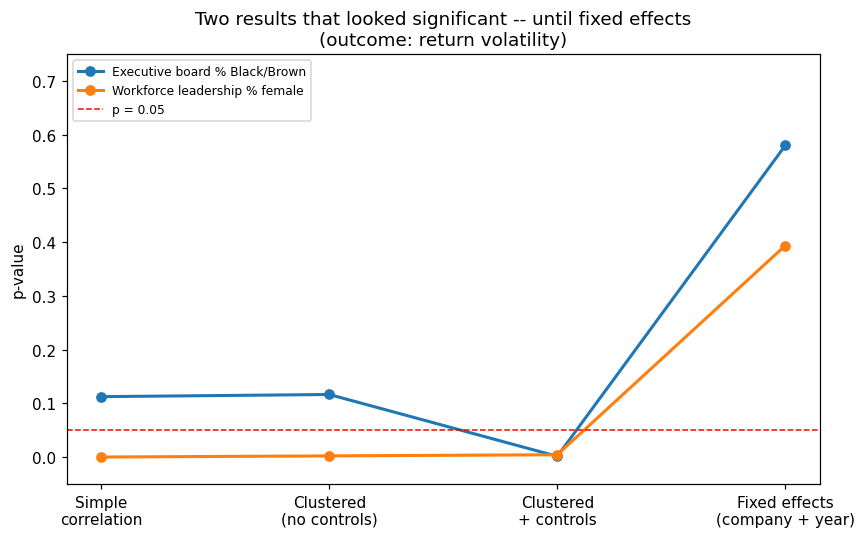

In [6]:
highlight = results[results['predictor'].isin(['pct_black_brown_exec', 'pct_female_leadership'])].copy()
highlight = highlight[highlight['outcome']=='return_volatility']

stages = ['simple_p', 'clustered_no_controls_p', 'clustered_with_controls_p', 'fe_p']
stage_labels = ['Simple\ncorrelation', 'Clustered\n(no controls)', 'Clustered\n+ controls', 'Fixed effects\n(company + year)']

fig, ax = plt.subplots(figsize=(8, 5))
for _, row in highlight.iterrows():
    ys = [row[s] for s in stages]
    label = 'Executive board % Black/Brown' if 'exec' in row['predictor'] else 'Workforce leadership % female'
    ax.plot(stage_labels, ys, marker='o', linewidth=2, label=label)

ax.axhline(0.05, color='red', linestyle='--', linewidth=1, label='p = 0.05')
ax.set_ylabel('p-value')
ax.set_title('Two results that looked significant -- until fixed effects\n(outcome: return volatility)')
ax.legend(fontsize=8, loc='upper left')
ax.set_ylim(-0.05, 0.75)
plt.tight_layout()
plt.savefig('figures/looks_real_until_fe.png', bbox_inches='tight')
plt.show()


**Reading this chart**: both lines dip toward significance (below the red p=0.05 line) at the "clustered + controls" stage, then jump back up once company and year fixed effects are added. This is the exact pattern the main thesis's `panel_model_results.md` documents for management-report returns -- a naive-or-controlled association that turns out to be a stable cross-company pattern (e.g. industry, size) rather than a real within-company effect. It shows up here too, in a completely unrelated dataset and research question, which is worth taking seriously as a general lesson rather than a one-off.

For the executive-board-race result, the confound looks like it could be size-adjacent (though not tested as precisely as the v1 board result, where size alone fully explained it). For the workforce-leadership-gender result, it explicitly is **not** size -- correlation with `ln_total_assets` is weak and the wrong sign to produce this mechanically -- so whatever's driving it (industry composition is the leading candidate, not confirmed) is a different confound than the one caught in the first pass.

## 5. Cost of debt: a clean null throughout

In [7]:
cod_results = results[results['outcome']=='cost_of_debt_proxy'][['predictor','simple_p','clustered_with_controls_p','fe_p']]
cod_results.columns = ['Predictor', 'Simple corr. (p)', 'Clustered + controls (p)', 'Fixed effects (p)']
cod_results.round(3)


,Predictor,Simple corr. (p),Clustered + controls (p),Fixed effects (p)
0,pct_female_board,0.609,0.714,0.744
1,pct_black_brown_board,0.904,0.827,0.204
2,has_black_brown_board,0.445,0.373,0.122
3,pct_female_exec,0.315,0.350,0.407
4,pct_black_brown_exec,0.153,0.397,0.903
5,pct_female_leadership,0.142,0.262,0.840
6,pct_black_brown_leadership,0.392,0.547,0.707


No predictor -- board, executive, or workforce-leadership; gender or race -- comes close to significance against the cost-of-debt proxy at any stage. This is the more straightforward null of the two outcomes tested.

## 6. Bottom line

- **The novelty gap is real** (verified adversarially -- see `novelty_verification.md`), and this notebook shows the underlying data is rich, well-covered (101-104/111 companies), and tells a striking story on its own (median board racial diversity: 0%).
- **Cost of debt: null everywhere.** Board/executive/leadership diversity, gender or race, shows no relationship at any stage of testing.
- **Return volatility: two results looked real through three stages of rigor, and both failed the fourth** (company+year fixed effects) -- the same lesson the main thesis learned from its own management-report return result, now observed independently in a second, unrelated dataset.
- **Net**: a well-documented, thoroughly-tested null, with a genuine, verified literature contribution (characterizing the gap itself) even though no result survived to become a "finding" in the stronger sense the main thesis would need.

See the top-level conversation for the verdict on how this compares to the main thesis as a use of the remaining time before the qualification exam.
